ESCENARIO 03 GEMINI - CON REGLAS, VERSIÓN GRATIS

     REPORTE DE CONTROL DE PROYECTO Y AVANCE FÍSICO
Avance Físico Consolidado: 68.42%

Avance por Disciplina:
  - Civil: 78.57%
  - Eléctrica: 0.00%
  - FalsaDisciplina: 50.00%
  - Instrumentación: 100.00%
  - Mecánica estática: 50.00%
  - Rotativa: 100.00%

Indicadores del Valor Ganado (EVM):
  - Valor Planificado (PV): USD 21,900.00
  - Valor Ganado (EV):      USD 26,000.00
  - Costo Real (AC):        USD 25,500.00
  - SPI: 1.19 (Adelanto)
  - CPI: 1.02 (Ahorro)

Lista de Inconsistencias Detectadas:
  [ALERTA] Actividad ACT-002: cantidad_ejecutada (60) es mayor que cantidad_planificada (50).
  [ALERTA] Actividad ACT-005: peso_presupuesto_usd (-1000) es nulo, negativo o ausente.
  [ALERTA] Actividad ACT-006: disciplina no reconocida 'FalsaDisciplina'.
  [ALERTA] Actividad ACT-007: unidad no reconocida 'litros'.
  [ALERTA] Actividad ACT-007: avance_planificado_pct (1.2) fuera del rango [0, 1].
  [ALERTA] ID de actividad duplicado: ACT-001


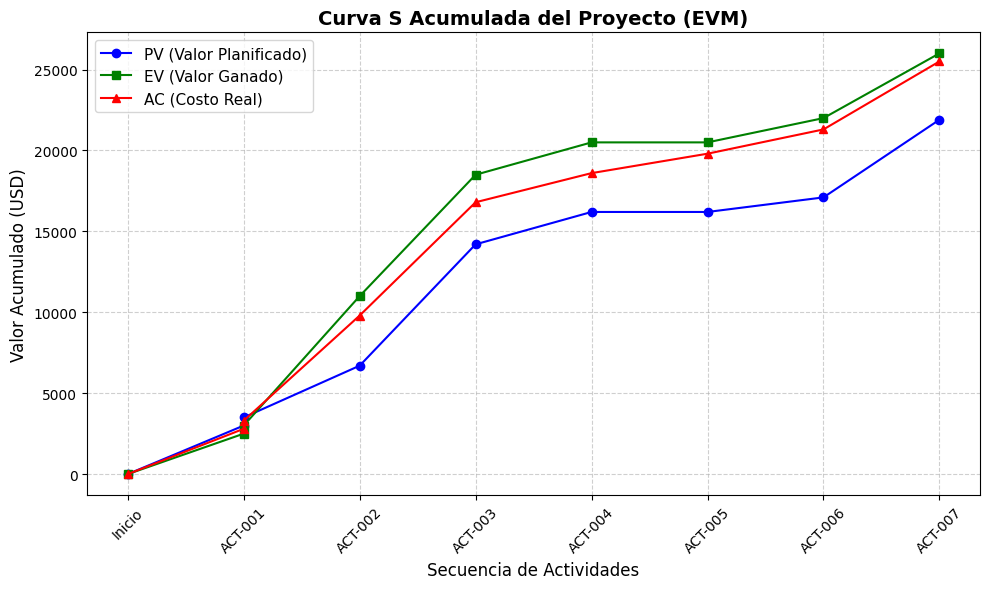

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import io

# ==========================================
# 1. CREADOR DE ARCHIVO DE PRUEBA (Para Google Colab)
# ==========================================
# Creamos un dataset de prueba para simular el entorno y que corra de inmediato.
csv_content = """id_actividad,disciplina,descripcion,unidad,cantidad_planificada,cantidad_ejecutada,peso_presupuesto_usd,avance_planificado_pct,costo_real_usd
ACT-001,Civil,Excavación cimientos,m3,100,50,5000,0.60,2800
ACT-002,Civil,Concreto zapata,m3,50,60,8000,0.40,6500
ACT-003,Mecánica estática,Montaje tanque,und,2,1,15000,0.50,7000
ACT-004,Instrumentación,Calibración válvulas,und,10,10,2000,1.00,1800
ACT-005,Eléctrica,Tendido de cables,m,500,250,-1000,0.50,1200
ACT-006,FalsaDisciplina,Tubería errónea,pulg_diam,10,5,3000,0.30,1500
ACT-007,Rotativa,Bomba centrífuga,litros,1,1,4000,1.20,4200
ACT-001,Civil,Duplicado ID,m3,10,5,1000,0.50,500
"""

filename = "02_Dataset_Base_STAP.csv"
with open(filename, "w", encoding="utf-8") as f:
    f.write(csv_content.strip())

# ==========================================
# 2. PROCESAMIENTO Y CÁLCULOS
# ==========================================

# Carga de datos
df = pd.read_csv(filename, encoding="utf-8")

# Listas de inconsistencias
inconsistencias = []

# Catálogos de validación
UNIDADES_VALIDAS = {'pulg_diam', 'kg', 'm', 'm2', 'm3', 'und'}
DISCIPLINAS_VALIDAS = {'Civil', 'Mecánica estática', 'Rotativa', 'Instrumentación', 'Eléctrica'}

# Validaciones fila por fila
ids_vistos = set()
for idx, row in df.iterrows():
    act_id = row['id_actividad']

    # ID duplicado
    if act_id in ids_vistos:
        inconsistencias.append(f"ID de actividad duplicado: {act_id}")
    else:
        ids_vistos.add(act_id)

    # Cantidad ejecutada mayor que la planificada
    if row['cantidad_ejecutada'] > row['cantidad_planificada']:
        inconsistencias.append(f"Actividad {act_id}: cantidad_ejecutada ({row['cantidad_ejecutada']}) es mayor que cantidad_planificada ({row['cantidad_planificada']}).")

    # Peso presupuestal nulo, negativo o ausente
    if pd.isna(row['peso_presupuesto_usd']) or row['peso_presupuesto_usd'] <= 0:
        inconsistencias.append(f"Actividad {act_id}: peso_presupuesto_usd ({row['peso_presupuesto_usd']}) es nulo, negativo o ausente.")

    # Unidad no reconocida
    if row['unidad'] not in UNIDADES_VALIDAS:
        inconsistencias.append(f"Actividad {act_id}: unidad no reconocida '{row['unidad']}'.")

    # Disciplina no reconocida
    if row['disciplina'] not in DISCIPLINAS_VALIDAS:
        inconsistencias.append(f"Actividad {act_id}: disciplina no reconocida '{row['disciplina']}'.")

    # Avance planificado pct fuera de rango [0, 1]
    if not (0 <= row['avance_planificado_pct'] <= 1):
        inconsistencias.append(f"Actividad {act_id}: avance_planificado_pct ({row['avance_planificado_pct']}) fuera del rango [0, 1].")

# Regla de cálculo 1: Avance de cada actividad acotado a [0, 1]
# Evitar división por cero si cantidad_planificada es 0
df['avance_actividad'] = (df['cantidad_ejecutada'] / df['cantidad_planificada']).fillna(0).clip(0, 1)

# Asegurar pesos válidos para los cálculos agregados (para evitar distorsiones por valores negativos/nulos)
df['peso_calculo'] = df['peso_presupuesto_usd'].apply(lambda x: x if (not pd.isna(x) and x > 0) else 0)

# Regla de cálculo 2: Avance físico consolidado
suma_pesos = df['peso_calculo'].sum()
if suma_pesos > 0:
    avance_fisico_consolidado = (df['avance_actividad'] * df['peso_calculo']).sum() / suma_pesos
else:
    avance_fisico_consolidado = 0

# Regla de cálculo 3: Avance por disciplina
avances_disciplina = {}
for g_name, g_df in df.groupby('disciplina'):
    g_suma_pesos = g_df['peso_calculo'].sum()
    if g_suma_pesos > 0:
        av_disp = (g_df['avance_actividad'] * g_df['peso_calculo']).sum() / g_suma_pesos
    else:
        av_disp = 0
    avances_disciplina[g_name] = av_disp

# Regla de cálculo 4: Valor Ganado (EVM)
pv_total = (df['peso_calculo'] * df['avance_planificado_pct']).sum()
ev_total = (df['peso_calculo'] * df['avance_actividad']).sum()
ac_total = df['costo_real_usd'].fillna(0).sum()

spi = ev_total / pv_total if pv_total > 0 else 0
cpi = ev_total / ac_total if ac_total > 0 else 0

# Interpretación de indicadores
interpretacion_spi = "Adelanto" if spi >= 1.0 else "Atraso"
interpretacion_cpi = "Ahorro" if cpi >= 1.0 else "Sobrecosto"

# ==========================================
# 3. GENERACIÓN DE REPORTES EN PANTALLA
# ==========================================

print("==================================================================")
print("     REPORTE DE CONTROL DE PROYECTO Y AVANCE FÍSICO")
print("==================================================================")
print(f"Avance Físico Consolidado: {avance_fisico_consolidado * 100:.2f}%\n")

print("Avance por Disciplina:")
for disp, valor in avances_disciplina.items():
    print(f"  - {disp}: {valor * 100:.2f}%")

print("\nIndicadores del Valor Ganado (EVM):")
print(f"  - Valor Planificado (PV): USD {pv_total:,.2f}")
print(f"  - Valor Ganado (EV):      USD {ev_total:,.2f}")
print(f"  - Costo Real (AC):        USD {ac_total:,.2f}")
print(f"  - SPI: {spi:.2f} ({interpretacion_spi})")
print(f"  - CPI: {cpi:.2f} ({interpretacion_cpi})")

print("\nLista de Inconsistencias Detectadas:")
if inconsistencias:
    for inc in inconsistencias:
        print(f"  [ALERTA] {inc}")
else:
    print("  No se detectaron inconsistencias en el conjunto de datos.")
print("==================================================================")

# ==========================================
# 4. GENERACIÓN DE GRÁFICA (Curva S)
# ==========================================

# Para trazar curvas acumuladas ordenamos cronológicamente o por secuencia lógica de IDs
df_sorted = df.sort_values(by='id_actividad').copy()

# Calculamos los componentes acumulados basados en el peso de cálculo
df_sorted['PV_acum'] = (df_sorted['peso_calculo'] * df_sorted['avance_planificado_pct']).cumsum()
df_sorted['EV_acum'] = (df_sorted['peso_calculo'] * df_sorted['avance_actividad']).cumsum()
df_sorted['AC_acum'] = df_sorted['costo_real_usd'].fillna(0).cumsum()

# Añadir un punto cero inicial para mejorar la estética visual de la curva S
eje_x = ['Inicio'] + df_sorted['id_actividad'].tolist()
pv_curve = [0] + df_sorted['PV_acum'].tolist()
ev_curve = [0] + df_sorted['EV_acum'].tolist()
ac_curve = [0] + df_sorted['AC_acum'].tolist()

plt.figure(figsize=(10, 6))
plt.plot(eje_x, pv_curve, marker='o', linestyle='-', color='blue', label='PV (Valor Planificado)')
plt.plot(eje_x, ev_curve, marker='s', linestyle='-', color='green', label='EV (Valor Ganado)')
plt.plot(eje_x, ac_curve, marker='^', linestyle='-', color='red', label='AC (Costo Real)')

plt.title('Curva S Acumulada del Proyecto (EVM)', fontsize=14, fontweight='bold')
plt.xlabel('Secuencia de Actividades', fontsize=12)
plt.ylabel('Valor Acumulado (USD)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()

# Mostrar gráfico en la celda
plt.show()